<a href="https://colab.research.google.com/github/yiqi0806-collab/Sensitive-annlysis/blob/main/gas_with_copula.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from scipy.stats import t as student_t
from scipy.stats import lognorm
from typing import Callable, Optional
from scipy.special import roots_legendre
import numpy as np
import numpy.random as R
import time
from scipy.stats import qmc
from scipy.stats import norm
from scipy.stats import chi2
from scipy import stats
from scipy.integrate import newton_cotes
import random
import math
import matplotlib.pyplot as plt
from numpy.linalg import eig
%matplotlib inline
from scipy.integrate import solve_ivp, simpson

def _gauss_legendre_01(n: int):
    # GL on (0,1): map (-1,1) -> (0,1)
    t, w = roots_legendre(n)
    s = 0.5*(t + 1.0)     # nodes in (0,1)
    w = 0.5*w             # sum to 1
    return s, w

def calc_C_normal(
    f: Callable[[np.ndarray], np.ndarray],
    X: np.ndarray,
    n_points: int = 10,
    return_AS: bool = False,
    clip_eps: float = 1e-12
):
    """
    C matrix for iid N(0,1) inputs.
    Uses change of variable u = Phi(v), v = Phi^{-1}(u),
    so the integral is still over (0,1).
    """
    M, d = X.shape
    A = np.zeros((M, d), dtype=float)
    S = np.zeros((M, d), dtype=float)

    s_nodes, s_w = _gauss_legendre_01(n_points)
    f_z = f(X)

    for i in range(M):
        z = X[i]
        fz = f_z[i]

        for j in range(d):
            zj = z[j]
            uj = norm.cdf(zj)

            # --- left part: u in [0, uj] ---
            if uj > 0.0:
                u_left = uj * s_nodes
                v_left = norm.ppf(u_left)

                eval_left = np.tile(z, (n_points, 1))
                eval_left[:, j] = v_left
                f_left = f(eval_left)

                qL = (f_left - fz) / (v_left - zj)
                JL = uj   # du = uj ds

                A[i, j] += np.dot(qL, s_w) * JL
                S[i, j] += np.dot(qL * qL, s_w) * JL

            # --- right part: u in [uj, 1] ---
            if uj < 1.0:
                u_right = uj + (1.0 - uj) * s_nodes
                v_right = norm.ppf(u_right)

                eval_right = np.tile(z, (n_points, 1))
                eval_right[:, j] = v_right
                f_right = f(eval_right)

                qR = (f_right - fz) / (v_right - zj)
                JR = 1.0 - uj

                A[i, j] += np.dot(qR, s_w) * JR
                S[i, j] += np.dot(qR * qR, s_w) * JR

    C = (A.T @ A) / M
    np.fill_diagonal(C, S.mean(axis=0))

    C = 0.5 * (C + C.T)
    w, _ = np.linalg.eigh(C)
    if w.min() < -clip_eps:
        C[np.diag_indices_from(C)] = np.maximum(np.diag(C), 0.0)

    return (C, A, S) if return_AS else C

def calc_C(
    f: Callable[[np.ndarray], np.ndarray],
    X: np.ndarray,
    n_points: int = 10,
    g: Optional[Callable[[np.ndarray], np.ndarray]] = None,  # 边缘密度；均匀时可缺省
    return_AS: bool = False,  # 如需调试可顺带返回 A,S
    clip_eps: float = 1e-12   # 数值误差矫正
):
    """
    直接返回“正确的”敏感度矩阵 C（对称 PSD）：
      - 对角: E_z[ ∫ q_i(v;z)^2 dv ]
      - 非对角: E_z[ (∫ q_i dv)(∫ q_j dv) ]
    不增加任何 f 调用；只在同一批节点上额外做了平方与加权。
    """
    M, d = X.shape
    A = np.zeros((M, d), dtype=float)   # A[i,j] = ∫ q_i dv  （非对角用）
    S = np.zeros((M, d), dtype=float)   # S[i,j] = ∫ q_i^2 dv（对角用）

    s_nodes, s_w = _gauss_legendre_01(n_points)
    f_z = f(X)                          # 基点 f(z) 只算一次

    for i in range(M):
        z  = X[i]
        fz = f_z[i]

        for j in range(d):
            zj = z[j]

            # --- 左段 v ∈ [0, z_j],  v = z_j * s  ---
            if zj > 0.0:
                eval_left = np.tile(z, (n_points, 1))
                eval_left[:, j] = zj * s_nodes
                f_left = f(eval_left)                 # 复用：不重复算

                vL = eval_left[:, j]
                qL = (f_left - fz) / (vL - zj)        # q = (f(v)-f(z)) / (v - z_j)

                gL = 1.0 if g is None else g(vL)
                JL = zj                               # dv = z_j ds

                A[i, j] += np.dot(qL,        s_w) * JL * gL
                S[i, j] += np.dot(qL * qL,   s_w) * JL * gL

            # --- 右段 v ∈ [z_j, 1],  v = z_j + (1-z_j) * s ---
            if zj < 1.0:
                eval_right = np.tile(z, (n_points, 1))
                eval_right[:, j] = zj + (1.0 - zj) * s_nodes
                f_right = f(eval_right)

                vR = eval_right[:, j]
                qR = (f_right - fz) / (vR - zj)

                gR = 1.0 if g is None else g(vR)
                JR = (1.0 - zj)

                A[i, j] += np.dot(qR,        s_w) * JR * gR
                S[i, j] += np.dot(qR * qR,   s_w) * JR * gR

    # 组装 C：先用 A^T A / M 放非对角，再用 S 的均值替换对角
    C = (A.T @ A) / M
    np.fill_diagonal(C, S.mean(axis=0))

    # 数值对称化 + 夹小负值到 0（避免舍入误差破坏 PSD）
    C = 0.5 * (C + C.T)
    w, _ = np.linalg.eigh(C)
    if w.min() < -clip_eps:
        # 仅当你特别在意 PSD，可用投影法强制 PSD；默认仅做微小裁剪
        C[np.diag_indices_from(C)] = np.maximum(np.diag(C), 0.0)

    return (C, A, S) if return_AS else C


def GAS_score(m,u,s):                         #m is how many eigenvalue we use
  gas_score = u[:,:m]**2@s[:m]/sum(u[:,:m]**2@s[:m])
  return gas_score


def _clip01(x, eps=1e-12):
    return np.clip(x, eps, 1.0 - eps)


def clayton_cdm(U, theta):
    """
    U: (m, n) independent U(0,1)
    return: (m, n) dependent uniforms from Clayton copula via CDM
    """
    U = np.asarray(U, dtype=float)
    U = _clip01(U)

    m, n = U.shape
    V = np.zeros((m, n), dtype=float)
    V[:, 0] = U[:, 0]

    for j in range(1, n):
        q = U[:, j]
        s = np.sum(V[:, :j] ** (-theta), axis=1)
        exponent = -1.0 / (j + 1.0 / theta)
        V[:, j] = (1.0 + (1.0 - j + s) * (q ** exponent - 1.0)) ** (-1.0 / theta)

    return _clip01(V)


def tcopula_cdm(U, P, nu):
    """
    U: (m, n) independent U(0,1)
    P: (n, n) correlation matrix
    nu: degrees of freedom
    return: (m, n) dependent uniforms from t-copula via CDM
    """
    U = np.asarray(U, dtype=float)
    U = _clip01(U)

    m, n = U.shape
    V = np.zeros((m, n), dtype=float)
    V[:, 0] = U[:, 0]

    for j in range(1, n):
        q = U[:, j]

        P_sub = P[:j+1, :j+1]
        Q = np.linalg.inv(P_sub)

        x = student_t.ppf(V[:, :j], df=nu)   # shape (m, j)

        P11 = P[:j, :j]
        P11_inv = np.linalg.inv(P11)

        g = np.einsum("mi,ij,mj->m", x, P11_inv, x)

        s1 = np.sqrt((nu + j) / (nu + g))
        s2 = (x @ Q[:j, j]) / np.sqrt(Q[j, j])

        inner = (student_t.ppf(q, df=nu + j) / s1 - s2) / np.sqrt(Q[j, j])
        V[:, j] = student_t.cdf(inner, df=nu)

    return _clip01(V)


def lognormal_inverse_cdf(U, mu_vec, sigma_vec):
    """
    U: (m, n) uniforms
    mu_vec, sigma_vec: length n
    return: (m, n) asset values
    """
    U = _clip01(np.asarray(U, dtype=float))
    mu_vec = np.asarray(mu_vec, dtype=float)
    sigma_vec = np.asarray(sigma_vec, dtype=float)

    m, n = U.shape
    X = np.zeros((m, n), dtype=float)

    for j in range(n):
        X[:, j] = lognorm.ppf(U[:, j], s=sigma_vec[j], scale=np.exp(mu_vec[j]))

    return X


def best_of_call_payoff(X_asset, K=0.0):
    """
    X_asset: (m, n)
    return: (m,)
    """
    return np.maximum(np.max(X_asset, axis=1) - K, 0.0)


def Func(
    X,
    copula="clayton",
    tau=0.4,
    K=0.0,
    nu=6.0,
    mu_vec=None,
    sigma_vec=None,
    P=None,
):
    """
    Overall function for GAS.

    Input
    -----
    X : ndarray, shape (m, n)
        Independent U(0,1) samples.
        m = number of samples
        n = dimension

    Output
    ------
    y : ndarray, shape (m,)
        Function values for each row of X
    """
    X = np.asarray(X, dtype=float)

    if X.ndim != 2:
        raise ValueError("Input X must be a 2D array of shape (m, n).")

    m, n = X.shape
    X = _clip01(X)

    if mu_vec is None:
        mu_vec = np.array([np.log(0.98)] + [np.log(1.1)] * (n - 1), dtype=float)

    if sigma_vec is None:
        sigma_vec = np.array([0.06] + [0.09] * (n - 1), dtype=float)

    copula = copula.lower()

    if copula == "clayton":
        theta = 2.0 * tau / (1.0 - tau)
        U_dep = clayton_cdm(X, theta)

    elif copula == "t":
        if P is None:
            rho = np.sin(np.pi * tau / 2.0)
            P = np.full((n, n), rho, dtype=float)
            np.fill_diagonal(P, 1.0)
        U_dep = tcopula_cdm(X, P, nu)

    else:
        raise ValueError("copula must be 'clayton' or 't'.")

    X_asset = lognormal_inverse_cdf(U_dep, mu_vec, sigma_vec)
    y = best_of_call_payoff(X_asset, K)

    return y

||C1-C2||_max = 0.008178323178378806
||C1-C3||_max = 0.005862503714466061
||C2-C3||_max = 0.012575578033399905
C1=
 [[0.07653288 0.03772061 0.02569175 0.02153626]
 [0.03772061 0.07437648 0.01799859 0.01528284]
 [0.02569175 0.01799859 0.05647237 0.00966687]
 [0.02153626 0.01528284 0.00966687 0.05546157]]
C2=
 [[0.08030777 0.03730267 0.02754282 0.02159486]
 [0.03730267 0.07399455 0.01814558 0.01412751]
 [0.02754282 0.01814558 0.06087676 0.00970391]
 [0.02159486 0.01412751 0.00970391 0.04728325]]
C3=
 [[0.08236067 0.03693836 0.02855648 0.02342963]
 [0.03693836 0.06851398 0.01830854 0.0151962 ]
 [0.02855648 0.01830854 0.06091172 0.01046615]
 [0.02342963 0.0151962  0.01046615 0.05985883]]
C1 eigenvalues = [0.13646804 0.04699718 0.04547365 0.03390443]
C1 gap12 = 0.08947086349943076
C1 gap23 = 0.0015235221073153157
C1 gap34 = 0.011569221089871039

C2 eigenvalues = [0.13818341 0.04819547 0.04212282 0.03396063]
C2 gap12 = 0.08998793648021297
C2 gap23 = 0.00607265543023313
C2 gap34 = 0.008162182

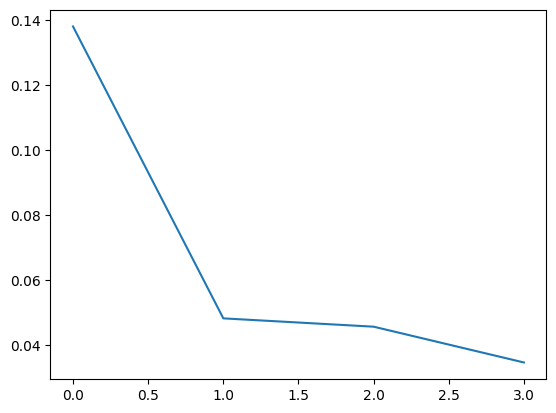

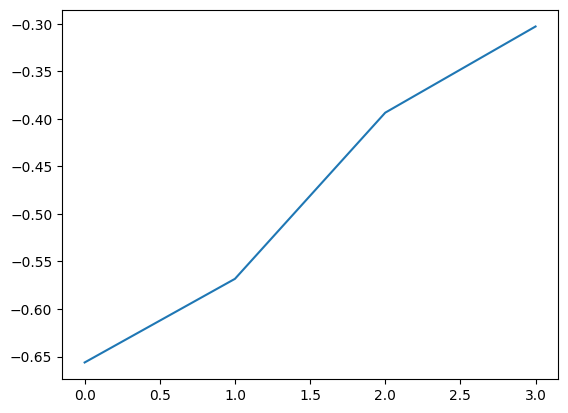

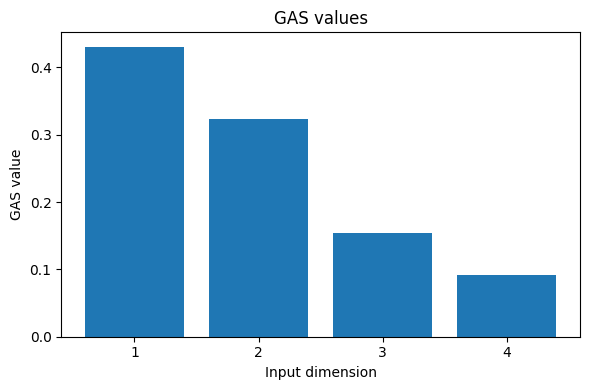

In [ ]:
dim=4
chi=10000
M2 = 5
X1 = R.uniform(1e-2, 1-1e-2, (int(chi/2/M2), dim))
X2 = R.uniform(1e-2, 1-1e-2, (int(chi/2/M2), dim))
X3 = R.uniform(1e-2, 1-1e-2, (int(chi/2/M2), dim))

C1 = calc_C(f=Func, X=X1, n_points=M2)
C2 = calc_C(f=Func, X=X2, n_points=M2)
C3 = calc_C(f=Func, X=X3, n_points=M2)

print("||C1-C2||_max =", np.max(np.abs(C1 - C2)))
print("||C1-C3||_max =", np.max(np.abs(C1 - C3)))
print("||C2-C3||_max =", np.max(np.abs(C2 - C3)))

print("C1=\n", C1)
print("C2=\n", C2)
print("C3=\n", C3)

for name, C in [("C1", C1), ("C2", C2), ("C3", C3)]:
    C = 0.5 * (C + C.T)
    s, u = np.linalg.eigh(C)
    s = np.sort(s)[::-1]
    print(name, "eigenvalues =", s)
    print(name, "gap12 =", s[0] - s[1])
    print(name, "gap23 =", s[1] - s[2])
    print(name, "gap34 =", s[2] - s[3])
    print()

C = calc_C(
            f=Func,
            X=R.uniform(1e-2, 1-1e-2, (int(chi/2/M2), dim)),
            n_points=M2
        )
#print("55555",C.shape)
#u, s, _ = np.linalg.svd(C.T.astype(float), full_matrices=False)

#gas_values8 = GAS_score(8, u, s)
#gas_values = GAS_score(1, u, s)

C = 0.5 * (C + C.T)                 # 数值对称
s, u = np.linalg.eigh(C)            # s 升序，u 的第 i 列 ↔ s[i]

# 需要降序：
idx = np.argsort(s)[::-1]
s = s[idx]
u = u[:, idx]

# 交给 GAS
gas_values  = GAS_score(1, u, s)

plt.plot(s)
plt.show()

plt.plot(u[:,0])
plt.show()


plt.figure(figsize=(6, 4))
plt.bar(np.arange(1, len(gas_values) + 1), gas_values)
plt.xlabel("Input dimension")
plt.ylabel("GAS value")
plt.title("GAS values")
plt.xticks(np.arange(1, len(gas_values) + 1))
plt.tight_layout()
plt.show()

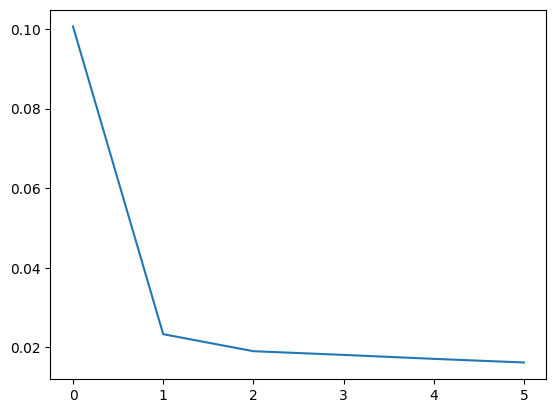

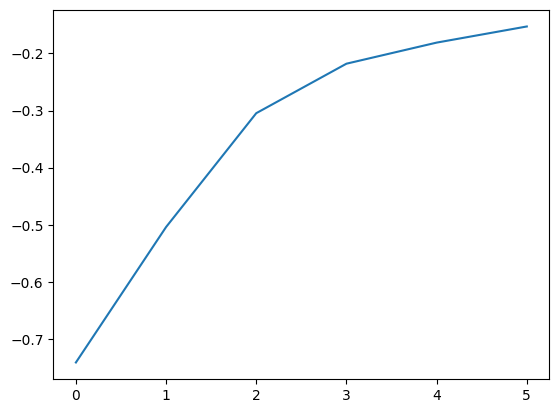

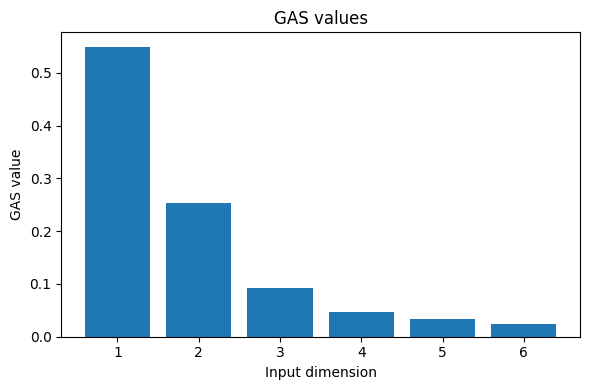

In [ ]:
dim=6
chi=10000
M2 = 5
C = calc_C(
    f=lambda X: Func(X, copula="t"),
    X=R.uniform(1e-2, 1-1e-2, (int(chi/2/M2), dim)),
    n_points=M2
)
C = 0.5 * (C + C.T)                 # 数值对称
s, u = np.linalg.eigh(C)            # s 升序，u 的第 i 列 ↔ s[i]

# 需要降序：
idx = np.argsort(s)[::-1]
s = s[idx]
u = u[:, idx]

# 交给 GAS
gas_values  = GAS_score(1, u, s)

plt.plot(s)
plt.show()

plt.plot(u[:,0])
plt.show()


plt.figure(figsize=(6, 4))
plt.bar(np.arange(1, len(gas_values) + 1), gas_values)
plt.xlabel("Input dimension")
plt.ylabel("GAS value")
plt.title("GAS values")
plt.xticks(np.arange(1, len(gas_values) + 1))
plt.tight_layout()
plt.show()

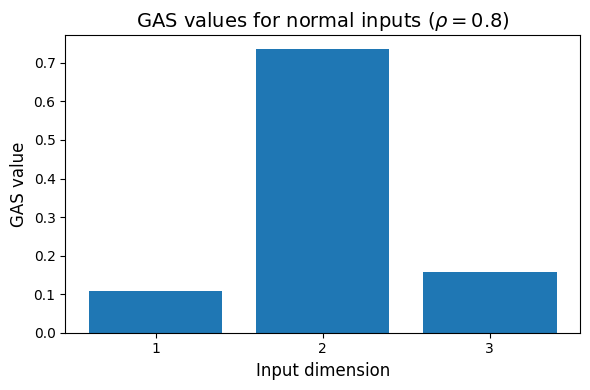

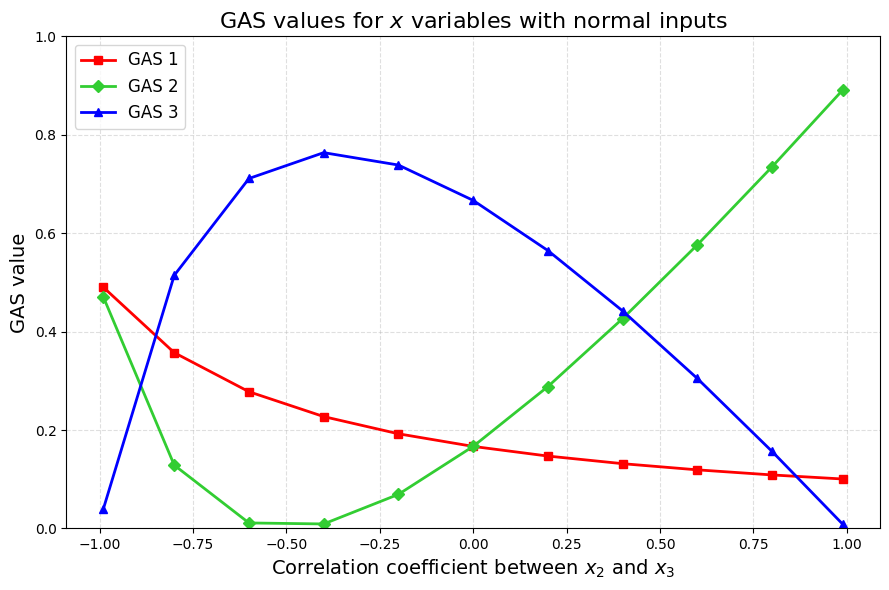

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# 1) Normal-input black-box model
# -----------------------------
def linear_model_test1_normal(Z: np.ndarray, rho: float = 0.8, sigma: float = 2.0) -> np.ndarray:
    """
    Input:
        Z ~ iid N(0,1), shape (N,3)

    Internal mapping:
        x1 = z1
        x2 = z2
        x3 = sigma*(rho*z2 + sqrt(1-rho^2)*z3)

    Output:
        y = x1 + x2 + x3
    """
    Z = np.asarray(Z, dtype=float)

    if Z.ndim == 1:
        Z = Z.reshape(1, -1)

    if Z.shape[1] != 3:
        raise ValueError("Z must have shape (N, 3) or (3,)")

    if not (-1 < rho < 1):
        raise ValueError("rho must satisfy -1 < rho < 1")

    if sigma <= 0:
        raise ValueError("sigma must be positive")

    z1 = Z[:, 0]
    z2 = Z[:, 1]
    z3 = Z[:, 2]

    x1 = z1
    x2 = z2
    x3 = sigma * (rho * z2 + np.sqrt(1.0 - rho**2) * z3)

    y = x1 + x2 + x3
    return y


# -----------------------------
# 2) Single rho: bar plot of GAS values
# -----------------------------
np.random.seed(0)

M = 10000
d = 3
X = np.random.randn(M, d)   # iid N(0,1)

C = calc_C_normal(
    f=lambda z: linear_model_test1_normal(z, rho=0.8, sigma=2.0),
    X=X,
    n_points=10
)

C = 0.5 * (C + C.T)
s, u = np.linalg.eigh(C)

idx = np.argsort(s)[::-1]
s = s[idx]
u = u[:, idx]

gas_values = GAS_score(1, u, s)
gas_values = gas_values / np.sum(gas_values)

plt.figure(figsize=(6, 4))
plt.bar(np.arange(1, len(gas_values) + 1), gas_values)
plt.xlabel("Input dimension", fontsize=12)
plt.ylabel("GAS value", fontsize=12)
plt.title(r'GAS values for normal inputs ($\rho=0.8$)', fontsize=14)
plt.xticks(np.arange(1, len(gas_values) + 1))
plt.tight_layout()
plt.show()


# -----------------------------
# 3) GAS values vs correlation
# -----------------------------
X = np.random.randn(M, d)   # reuse one sample set for smoother comparison
gas_all = []

rho_list = np.array([-0.99, -0.8, -0.6, -0.4, -0.2, 0.0, 0.2, 0.4, 0.6, 0.8, 0.99])

for rho in rho_list:
    C = calc_C_normal(
        f=lambda z: linear_model_test1_normal(z, rho=rho, sigma=2.0),
        X=X,
        n_points=10
    )

    C = 0.5 * (C + C.T)
    s, u = np.linalg.eigh(C)

    idx = np.argsort(s)[::-1]
    s = s[idx]
    u = u[:, idx]

    gas_values = GAS_score(1, u, s)
    gas_values = gas_values / np.sum(gas_values)
    gas_all.append(gas_values)

gas_all = np.array(gas_all)

# -----------------------------
# 4) Plot in a style similar to the Sobol figure
# -----------------------------
plt.figure(figsize=(9, 6))

plt.plot(rho_list, gas_all[:, 0], color='red', marker='s', linewidth=2, label='GAS 1')
plt.plot(rho_list, gas_all[:, 1], color='limegreen', marker='D', linewidth=2, label='GAS 2')
plt.plot(rho_list, gas_all[:, 2], color='blue', marker='^', linewidth=2, label='GAS 3')

plt.xlabel(r'Correlation coefficient between $x_2$ and $x_3$', fontsize=14)
plt.ylabel('GAS value', fontsize=14)
plt.title(r'GAS values for $x$ variables with normal inputs', fontsize=16)
plt.ylim(0, 1.0)
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

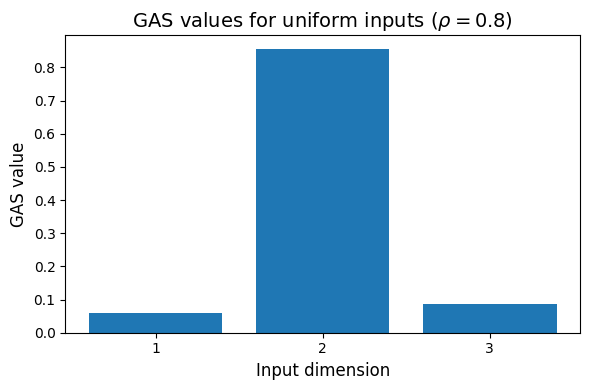

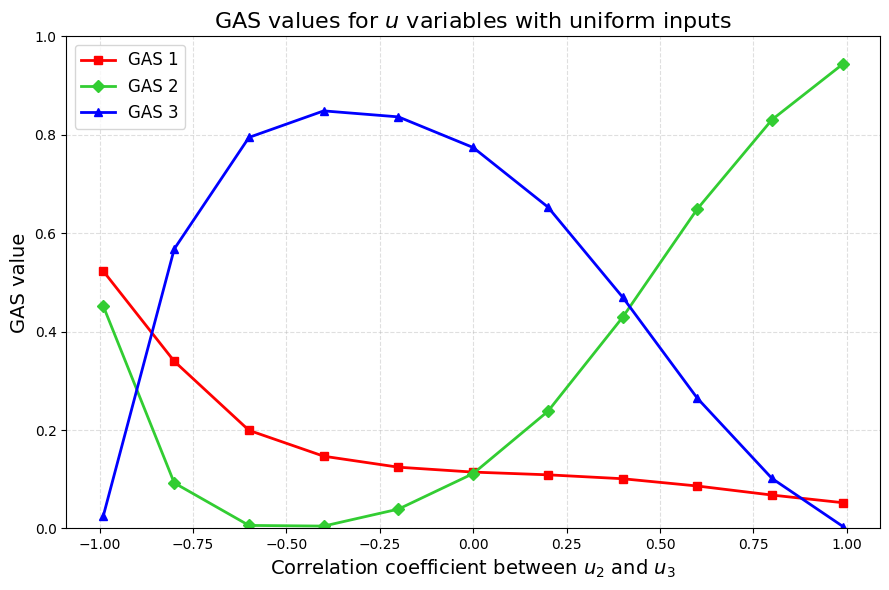

In [ ]:
from scipy.stats import norm
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# 1) Uniform-input black-box model
# -----------------------------
def linear_model_test1_uniform(U: np.ndarray, rho: float = 0.8, sigma: float = 2.0) -> np.ndarray:
    """
    Input:
        U ~ iid U(0,1), shape (N,3)

    Internal mapping:
        U -> Z via inverse normal CDF
        x1 = z1
        x2 = z2
        x3 = sigma*(rho*z2 + sqrt(1-rho^2)*z3)

    Output:
        y = x1 + x2 + x3
    """
    U = np.asarray(U, dtype=float)
    if U.ndim == 1:
        U = U.reshape(1, -1)

    U = np.clip(U, 1e-12, 1 - 1e-12)
    Z = norm.ppf(U)

    z1, z2, z3 = Z[:, 0], Z[:, 1], Z[:, 2]
    x1 = z1
    x2 = z2
    x3 = sigma * (rho * z2 + np.sqrt(1.0 - rho**2) * z3)

    return x1 + x2 + x3


# -----------------------------
# 2) Single rho: bar plot of GAS values
# -----------------------------
np.random.seed(0)

M = 10000
d = 3
X = np.random.rand(M, d)   # iid U(0,1)

C = calc_C(
    f=lambda u: linear_model_test1_uniform(u, rho=0.8, sigma=2.0),
    X=X,
    n_points=10
)

C = 0.5 * (C + C.T)
s, u = np.linalg.eigh(C)

idx = np.argsort(s)[::-1]
s = s[idx]
u = u[:, idx]

gas_values = GAS_score(1, u, s)
gas_values = gas_values / np.sum(gas_values)

plt.figure(figsize=(6, 4))
plt.bar(np.arange(1, len(gas_values) + 1), gas_values)
plt.xlabel("Input dimension", fontsize=12)
plt.ylabel("GAS value", fontsize=12)
plt.title(r'GAS values for uniform inputs ($\rho=0.8$)', fontsize=14)
plt.xticks(np.arange(1, len(gas_values) + 1))
plt.tight_layout()
plt.show()


# -----------------------------
# 3) GAS values vs correlation
# -----------------------------
X = np.random.rand(M, d)   # reuse one sample set for smoother comparison
gas_all = []

rho_list = np.array([-0.99, -0.8, -0.6, -0.4, -0.2, 0.0, 0.2, 0.4, 0.6, 0.8, 0.99])

for rho in rho_list:
    C = calc_C(
        f=lambda u: linear_model_test1_uniform(u, rho=rho, sigma=2.0),
        X=X,
        n_points=10
    )

    C = 0.5 * (C + C.T)
    s, u = np.linalg.eigh(C)

    idx = np.argsort(s)[::-1]
    s = s[idx]
    u = u[:, idx]

    gas_values = GAS_score(1, u, s)
    gas_values = gas_values / np.sum(gas_values)
    gas_all.append(gas_values)

gas_all = np.array(gas_all)

# -----------------------------
# 4) Plot in a style similar to the Sobol figure
# -----------------------------
plt.figure(figsize=(9, 6))

plt.plot(rho_list, gas_all[:, 0], color='red', marker='s', linewidth=2, label='GAS 1')
plt.plot(rho_list, gas_all[:, 1], color='limegreen', marker='D', linewidth=2, label='GAS 2')
plt.plot(rho_list, gas_all[:, 2], color='blue', marker='^', linewidth=2, label='GAS 3')

plt.xlabel(r'Correlation coefficient between $u_2$ and $u_3$', fontsize=14)
plt.ylabel('GAS value', fontsize=14)
plt.title(r'GAS values for $u$ variables with uniform inputs', fontsize=16)
plt.ylim(0, 1.0)
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

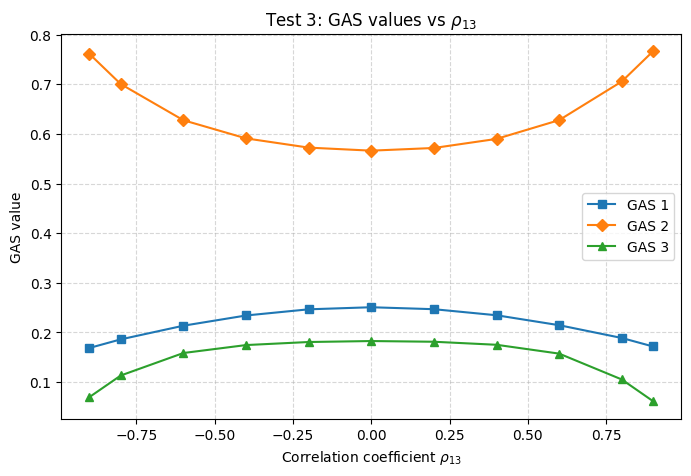

In [ ]:
from scipy.stats import norm

def ishigami_test3(U, rho13=0.0, a=7.0, b=0.1):
    U = np.asarray(U, dtype=float)
    if U.ndim == 1:
        U = U.reshape(1, -1)

    # independent uniforms -> standard normals
    Z = norm.ppf(np.clip(U, 1e-12, 1-1e-12))

    # correlation only between x1 and x3
    P = np.array([
        [1.0, 0.0, rho13],
        [0.0, 1.0, 0.0],
        [rho13, 0.0, 1.0]
    ])

    L = np.linalg.cholesky(P)
    Zc = Z @ L.T

    # back to dependent uniforms
    Udep = norm.cdf(Zc)

    # map to [-pi, pi]
    X = -np.pi + 2*np.pi*Udep

    x1, x2, x3 = X[:, 0], X[:, 1], X[:, 2]
    y = np.sin(x1) + a*np.sin(x2)**2 + b*(x3**4)*np.sin(x1)
    return y

M = 10000
d = 3
X = np.random.rand(M, d)   # iid U(0,1)

rho_list = np.array([-0.9, -0.8, -0.6, -0.4, -0.2, 0.0, 0.2, 0.4, 0.6, 0.8, 0.9])

gas_all = []

for rho in rho_list:
    C = calc_C(
        f=lambda z: ishigami_test3(z, rho13=rho, a=7.0, b=0.1),
        X=X,
        n_points=10
    )

    C = 0.5 * (C + C.T)
    s, u = np.linalg.eigh(C)

    idx = np.argsort(s)[::-1]
    s = s[idx]
    u = u[:, idx]

    gas_values = GAS_score(3, u, s)
    gas_values = gas_values / np.sum(gas_values)
    gas_all.append(gas_values)

gas_all = np.array(gas_all)

plt.figure(figsize=(8,5))
plt.plot(rho_list, gas_all[:,0], marker='s', label='GAS 1')
plt.plot(rho_list, gas_all[:,1], marker='D', label='GAS 2')
plt.plot(rho_list, gas_all[:,2], marker='^', label='GAS 3')
plt.xlabel(r'Correlation coefficient $\rho_{13}$')
plt.ylabel('GAS value')
plt.title(r'Test 3: GAS values vs $\rho_{13}$')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

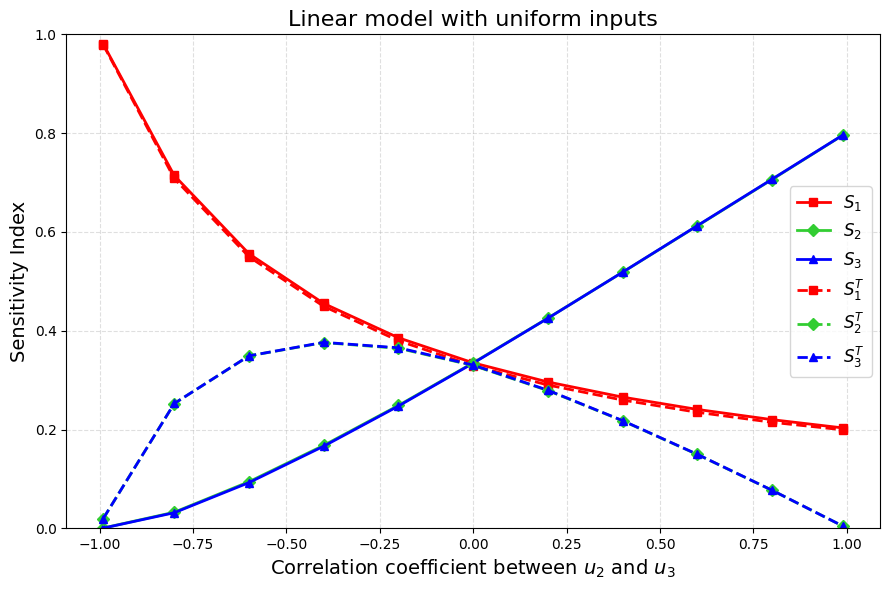

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# -----------------------------
# 1) 线性模型（用 u 记号）
# -----------------------------
def f_linear_uniform(U):
    # U shape: (N, 3)
    return U[:, 0] + U[:, 1] + U[:, 2]


# -----------------------------
# 2) 生成相关 Uniform(0,1) 样本
#    这里 rho_u 是 u2,u3 的实际 Pearson correlation
# -----------------------------
def sample_u_gaussian_copula_from_base(base_Z, rho_u):
    """
    base_Z : (N,3) iid N(0,1) base samples, reused for all rho to reduce noise
    rho_u  : target Pearson correlation Corr(u2, u3) for uniform marginals

    Gaussian copula identity:
        Corr(U2,U3) = (6/pi) * arcsin(rho_g/2)
    so
        rho_g = 2 * sin(pi * rho_u / 6)
    """
    rho_g = 2.0 * np.sin(np.pi * rho_u / 6.0)

    z1 = base_Z[:, 0]
    e2 = base_Z[:, 1]
    e3 = base_Z[:, 2]

    z2 = e2
    z3 = rho_g * e2 + np.sqrt(max(0.0, 1.0 - rho_g**2)) * e3

    Zc = np.column_stack([z1, z2, z3])
    U = norm.cdf(Zc)   # now each margin is Uniform(0,1)

    return U


# -----------------------------
# 3) 一阶敏感度指数: S_i = Var(E[Y|u_i]) / Var(Y)
#    用 1D 分箱近似条件期望
# -----------------------------
def estimate_first_order_1d(ui, y, nbins=120):
    var_y = np.var(y, ddof=0)
    if var_y <= 0:
        return np.nan

    idx = np.minimum((ui * nbins).astype(int), nbins - 1)

    counts = np.bincount(idx, minlength=nbins)
    sums = np.bincount(idx, weights=y, minlength=nbins)

    mask = counts > 0
    means = sums[mask] / counts[mask]
    weights = counts[mask] / counts.sum()

    mu = np.sum(weights * means)
    var_cond_mean = np.sum(weights * (means - mu)**2)

    return var_cond_mean / var_y


# -----------------------------
# 4) 总敏感度指数: S_i^T = 1 - Var(E[Y|u_-i]) / Var(Y)
#    用 2D 分箱近似条件期望
# -----------------------------
def estimate_total_order_2d(uj, uk, y, nbins=40):
    var_y = np.var(y, ddof=0)
    if var_y <= 0:
        return np.nan

    idx_j = np.minimum((uj * nbins).astype(int), nbins - 1)
    idx_k = np.minimum((uk * nbins).astype(int), nbins - 1)
    flat_idx = idx_j * nbins + idx_k

    ncell = nbins * nbins
    counts = np.bincount(flat_idx, minlength=ncell)
    sums = np.bincount(flat_idx, weights=y, minlength=ncell)

    mask = counts > 0
    means = sums[mask] / counts[mask]
    weights = counts[mask] / counts.sum()

    mu = np.sum(weights * means)
    var_cond_mean = np.sum(weights * (means - mu)**2)

    return 1.0 - var_cond_mean / var_y


# -----------------------------
# 5) 对一组 correlation 计算 S1,S2,S3,ST1,ST2,ST3
# -----------------------------
np.random.seed(0)

N = 200000
base_Z = np.random.randn(N, 3)

rho_list = np.array([-0.99, -0.8, -0.6, -0.4, -0.2, 0.0, 0.2, 0.4, 0.6, 0.8, 0.99])

S1_list, S2_list, S3_list = [], [], []
ST1_list, ST2_list, ST3_list = [], [], []

for rho_u in rho_list:
    U = sample_u_gaussian_copula_from_base(base_Z, rho_u)
    y = f_linear_uniform(U)

    u1, u2, u3 = U[:, 0], U[:, 1], U[:, 2]

    S1  = estimate_first_order_1d(u1, y, nbins=120)
    S2  = estimate_first_order_1d(u2, y, nbins=120)
    S3  = estimate_first_order_1d(u3, y, nbins=120)

    ST1 = estimate_total_order_2d(u2, u3, y, nbins=40)
    ST2 = estimate_total_order_2d(u1, u3, y, nbins=40)
    ST3 = estimate_total_order_2d(u1, u2, y, nbins=40)

    S1_list.append(S1)
    S2_list.append(S2)
    S3_list.append(S3)

    ST1_list.append(ST1)
    ST2_list.append(ST2)
    ST3_list.append(ST3)

S1_list  = np.array(S1_list)
S2_list  = np.array(S2_list)
S3_list  = np.array(S3_list)
ST1_list = np.array(ST1_list)
ST2_list = np.array(ST2_list)
ST3_list = np.array(ST3_list)


# -----------------------------
# 6) 画图
# -----------------------------
plt.figure(figsize=(9, 6))

plt.plot(rho_list, S1_list,  color='red', marker='s', linewidth=2, label=r'$S_1$')
plt.plot(rho_list, S2_list,  color='limegreen', marker='D', linewidth=2, label=r'$S_2$')
plt.plot(rho_list, S3_list,  color='blue', marker='^', linewidth=2, label=r'$S_3$')

plt.plot(rho_list, ST1_list, color='red', marker='s', linestyle='--', linewidth=2, label=r'$S_1^T$')
plt.plot(rho_list, ST2_list, color='limegreen', marker='D', linestyle='--', linewidth=2, label=r'$S_2^T$')
plt.plot(rho_list, ST3_list, color='blue', marker='^', linestyle='--', linewidth=2, label=r'$S_3^T$')

plt.xlabel(r'Correlation coefficient between $u_2$ and $u_3$', fontsize=14)
plt.ylabel('Sensitivity Index', fontsize=14)
plt.title(r'Linear model with uniform inputs', fontsize=16)
plt.ylim(0, 1.0)
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()